In [1]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/Colab Notebooks/fraud-project/'

Mounted at /content/drive


In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay,
    PrecisionRecallDisplay, f1_score
)

with open(DRIVE_PATH + 'processed_data.pkl', 'rb') as f:
    data = pickle.load(f)
with open(DRIVE_PATH + 'models.pkl', 'rb') as f:
    models = pickle.load(f)

X_test = data['X_test']
y_test = data['y_test']
lr     = models['lr']
rf     = models['rf']
xgb    = models['xgb']

print("Loaded!")

Loaded!


In [3]:
# ROC-AUC Scores
for name, model in [('Logistic Regression', lr), ('Random Forest', rf), ('XGBoost', xgb)]:
    proba = model.predict_proba(X_test)[:, 1]
    auc   = roc_auc_score(y_test, proba)
    print(f"{name:25} AUC: {auc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Logistic Regression       AUC: 0.5000
Random Forest             AUC: 0.8698
XGBoost                   AUC: 0.9300


In [4]:
# Classification Report
print("XGBoost Classification Report:")
print("="*50)

preds = xgb.predict(X_test)
print(classification_report(y_test, preds, target_names=['Legit','Fraud']))

XGBoost Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      0.96      0.98    113975
       Fraud       0.42      0.70      0.52      4133

    accuracy                           0.96    118108
   macro avg       0.70      0.83      0.75    118108
weighted avg       0.97      0.96      0.96    118108



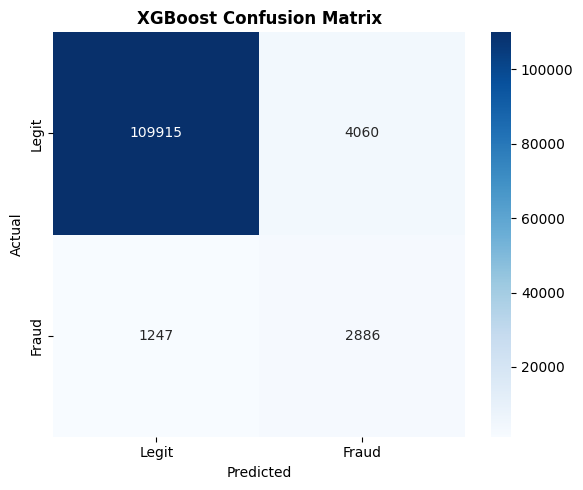

In [5]:
# Confusion Matrix
cm = confusion_matrix(y_test, preds)

fig, ax = plt.subplots(figsize=(6, 5))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit','Fraud'],
            yticklabels=['Legit','Fraud'], ax=ax)
ax.set_title('XGBoost Confusion Matrix', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


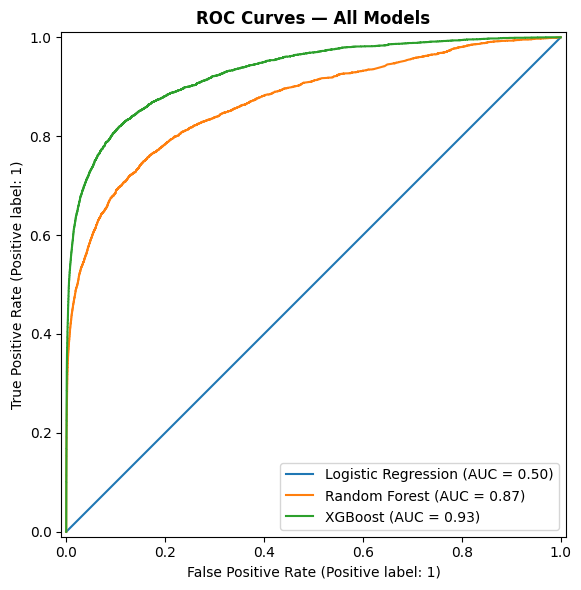

In [6]:
# ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in [('Logistic Regression', lr), ('Random Forest', rf), ('XGBoost', xgb)]:
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

ax.set_title('ROC Curves — All Models', fontweight='bold')
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


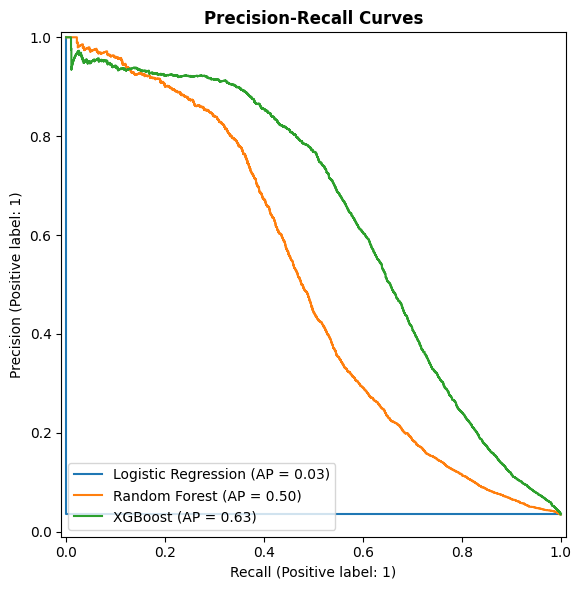

In [7]:
# Precision-Recall Curve
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in [('Logistic Regression', lr), ('Random Forest', rf), ('XGBoost', xgb)]:
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

ax.set_title('Precision-Recall Curves', fontweight='bold')
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Threshold Tuning
from sklearn.metrics import precision_score, recall_score

proba = xgb.predict_proba(X_test)[:, 1]

print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 45)

for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred_t = (proba >= t).astype(int)
    p = precision_score(y_test, pred_t)
    r = recall_score(y_test, pred_t)
    f = f1_score(y_test, pred_t)
    print(f"{t:>10.1f} {p:>10.4f} {r:>10.4f} {f:>10.4f}")

 Threshold  Precision     Recall         F1
---------------------------------------------
       0.3     0.2266     0.8110     0.3542
       0.4     0.3074     0.7566     0.4372
       0.5     0.4155     0.6983     0.5210
       0.6     0.5417     0.6366     0.5853
       0.7     0.6621     0.5647     0.6096


In [9]:
# Use threshold 0.4 for better fraud recall
BEST_THRESHOLD = 0.4

with open(DRIVE_PATH + 'best_model.pkl', 'wb') as f:
    pickle.dump({'model': xgb, 'threshold': BEST_THRESHOLD}, f)

print(f"Best model saved with threshold={BEST_THRESHOLD}")
print("Move to Notebook 5 — SHAP")

Best model saved with threshold=0.4
Move to Notebook 5 — SHAP
